/tmp/ipykernel_7240/4044690314.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["addiction_level"].fillna(df["addiction_level"].mode()[0], inplace=True)


After SMOTE: [4246 4246]

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       438
           1       1.00      1.00      1.00      1062

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500


Confusion Matrix:
 [[ 438    0]
 [   0 1062]]


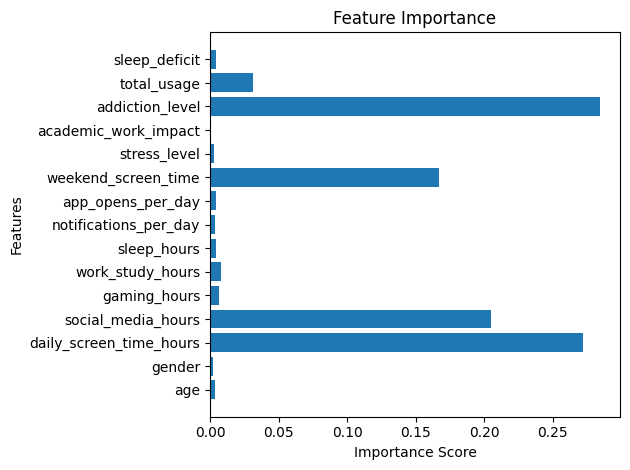


Model and scaler saved successfully!


In [10]:

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

#  2. Load Data
df = pd.read_csv("/content/drive/MyDrive/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")

#  3. Data Cleaning
# Drop IDs
df.drop(columns=["transaction_id", "user_id"], inplace=True)

# Handle missing values
df["addiction_level"].fillna(df["addiction_level"].mode()[0], inplace=True)

#  4. Feature Engineering
df["total_usage"] = (
    df["social_media_hours"] +
    df["gaming_hours"] +
    df["work_study_hours"]
)

df["sleep_deficit"] = 8 - df["sleep_hours"]

#  5. Encoding
le = LabelEncoder()

categorical_cols = ["gender", "stress_level", "academic_work_impact", "addiction_level"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

#  6. Features & Target
X = df.drop(columns=["addicted_label"])
y = df["addicted_label"]

#  7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Save feature names
feature_names = X.columns

#  8. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  9. SMOTE (Handle Class Imbalance)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

#  10. Model Training
model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
model.fit(X_train, y_train)

#  11. Evaluation
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

#  12. Feature Importance
importance = model.feature_importances_

plt.figure()
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  13. Save Model
import joblib

joblib.dump(model, "smartphone_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully!")